In [1]:
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from ebltable.tau_from_model import OptDepth

from elfdannagalac.dmspectrum import (
    dmspectra,
    dmdecayNorm,
    Qe_dmdecay,
    weigths_PL_sim
)

# Description

The notebook shows how to convert from the CRpropa output to the expected differential photon rate and flux for decay of DM in the cluster A 193.

The weightning calculation is basically scale the energy of the simulated spectrum by the probability of electrons emitted at that energy from the expected spectrum from DM decays. We also need to take into account the injection rate of electrons from DM decay and the number of simulated particles used in the simulation. Then, the spectral weight is:

$W\left(dn_\text{sim},dn_\text{DM}\right) = \frac{Q_e^\text{DM}}{n_\text{sim}}\times\frac{\text{PDF}_\text{DM}(E_e)}{\text{PDF}_\text{sim}(E_e)}$

The spectrum from DM decay is taken from the class `dmspectra` that also return an interpolator that can be used in integrations.

The example file used here only considers 200K electrons injected. For the calculation of the expected photon spectrum from the DM decay, we assume a DM candidate with a mass of 10 TeV decaying to $\tau$ leptons with a lifetime of $10^{27}~\text{s}$.

CRpropa also give us and additional weight $W_\text{CRpropa}$ that comes from the simulation and refers to thining. The total weight is then:

$W = W\left(dn_\text{sim},dn_\text{DM}\right)\times W_\text{CRpropa}$

Also, if we want the SED, I am applying and additional weight that is the photon energy squared.

In [2]:
# fname = "/data/disk01/home/skerzot/EDMClusters/A193decay.fits.gz"
fname = "/mnt/mydisk/sergio/edmclusters/Run001/A193decay.fits.gz"
hdu   = fits.open(fname)[1]


eng_unit = u.Unit(hdu.data.columns["E"].unit)

e_gamma   = hdu.data["E"]*eng_unit
e_weigths = hdu.data["W"]
e_source  = hdu.data["E0"]*eng_unit


print(f"Minimum photon energy: {e_gamma.min()}")
print(f"Minimum photon energy: {e_gamma.max()}")
print(f"Minimum electron energy: {e_source.min()}")
print(f"Minimum electron energy: {e_source.max()}")


Minimum photon energy: 1.43394e-06 GeV
Minimum photon energy: 53673.6 GeV
Minimum electron energy: 100.001 GeV
Minimum electron energy: 99589.9 GeV


In [3]:
emin_sim = 100*u.GeV
emax_sim = 100*u.TeV


In [4]:
dmmass  = 1e+4*u.GeV
emin_dm = 100*u.GeV
emax_dm = 100*u.TeV
channel = 'tau'

cosmix_spec = dmspectra.dmspectrum(
    dmmass.value,
    emin_dm.value,
    emax_dm.value,
    channel,
    process="decay"
)

dnde_e_real = cosmix_spec.spectrum()
dm_interp   = cosmix_spec.interpolator()

In [5]:
dmNorm = dmdecayNorm(
    dm_interp,
    cosmix_spec.mass*u.GeV,
    emin_dm,
    emax_dm,
)

print(dmNorm)

0.0012220797694323209


In [6]:
m200   = 2.40435e14 * u.Msun
tau_dm = 1e27*u.s

ndot_exp = Qe_dmdecay(
    dmmass,
    m200,
    tau_dm,
    dmNorm
)

print(f"Injection rate of electrons from DM decay is: {ndot_exp}")

Injection rate of electrons from DM decay is: 4.118547026472017e+38 1 / s


In [7]:
n_sim = 2e5 

dmw = weigths_PL_sim(
    n_sim,
    ndot_exp,
    dmmass,
    e_source,
    emin_sim,
    emax_sim,
    dm_interp,
    dmNorm,
)

print(dmw)


[3.01543803e+36 3.01543803e+36 3.01543803e+36 ... 4.56253973e+35
 4.56253973e+35 4.56253973e+35] 1 / s


# Getting the photon rate

Text(0, 0.5, 'Counts rate [1/s]')

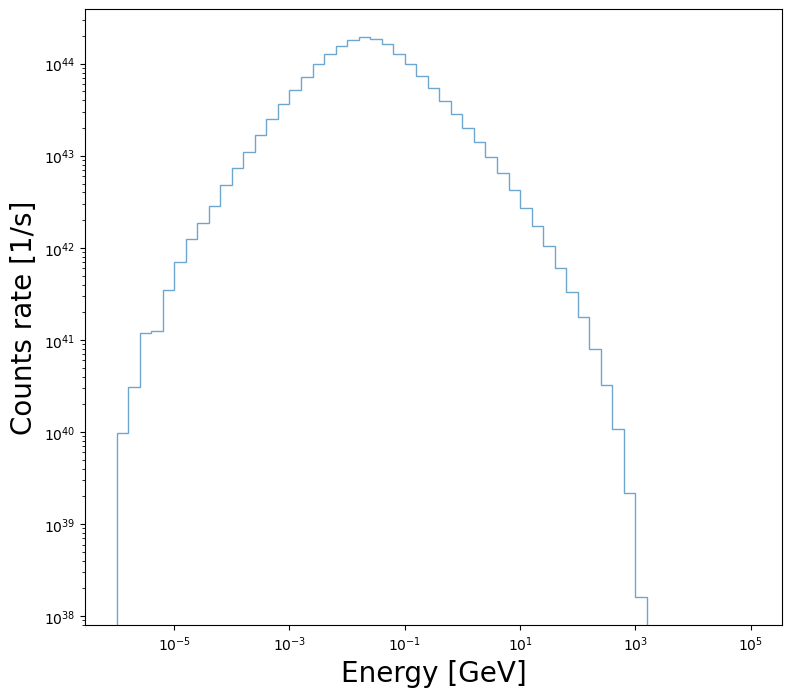

In [8]:
delta_loge = 0.2

engs = 10**np.arange(
    -6,5+delta_loge,step=delta_loge
)*u.GeV

binwidths = np.diff(engs)

counts_hist,_ = np.histogram(e_gamma.value,bins=engs.value,weights=e_weigths*dmw.value)

_,ax = plt.subplots(figsize=(9,8))

ax.stairs(counts_hist,engs.value,facecolor="pink",alpha=0.65)
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy [GeV]",fontsize=20)
ax.set_ylabel("Counts rate [1/s]",fontsize=20)
# ax.set_title("Counts spectrum without reweightening",fontsize=18)

# Get the differential photon rate (dN/dE/dt)

Text(0, 0.5, '$\\frac{{\\rm d}N}{{\\rm d}E {\\rm d}t}~[\\text{GeV}^{-1}~\\text{s}^{-1}]$')

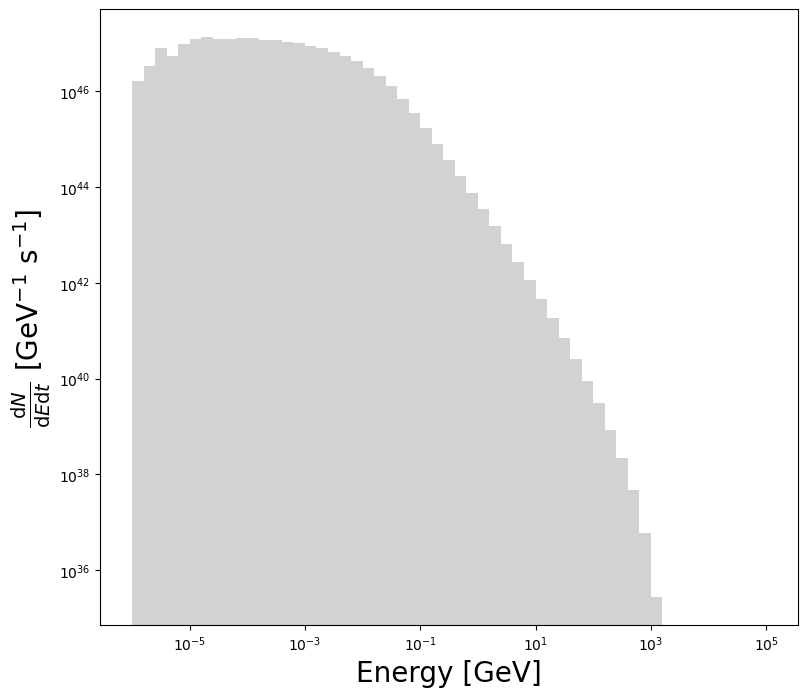

In [9]:
# for this, we also need the bin width (but not in log scale :p)
# the units in this case are particles per unit energy per unit time
# or simply particles / GeV / s

_,ax = plt.subplots(figsize=(9,8))

ax.stairs(counts_hist/binwidths.value,engs.value,facecolor="gray",fill=True,alpha=0.35)
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy [GeV]",fontsize=20)
ax.set_ylabel(r"$\frac{{\rm d}N}{{\rm d}E {\rm d}t}~[\text{GeV}^{-1}~\text{s}^{-1}]$",fontsize=20)
# ax.set_title("Counts spectrum without reweightening",fontsize=18)

# Get the $\nu L_\nu$ (E2dN/dE/dt)

Text(0, 0.5, '$\\frac{E^2{\\rm d}N}{{\\rm d}E {\\rm d}t}~[\\text{GeV}~\\text{s}^{-1}]$')

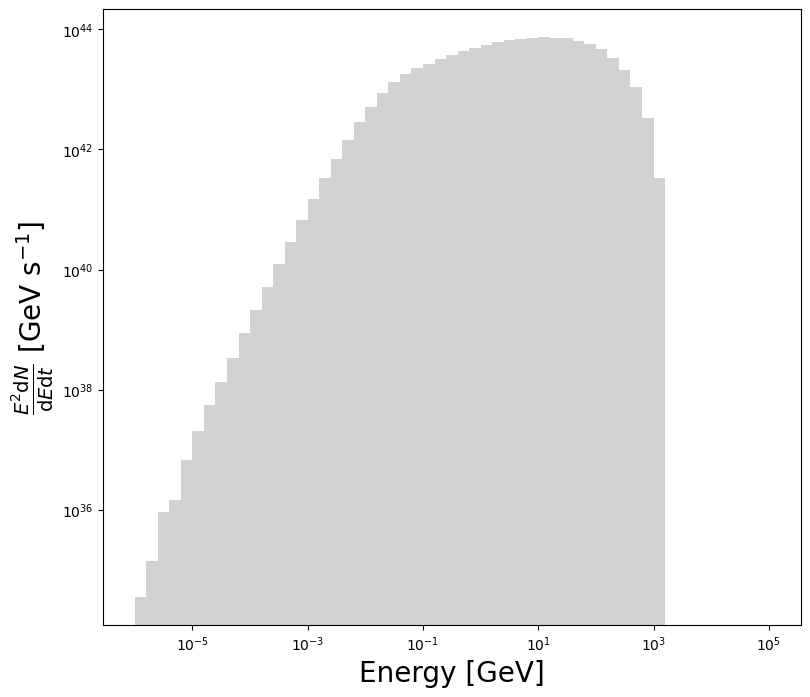

In [10]:
counts_hist,_ = np.histogram(e_gamma.value,bins=engs.value,weights=e_weigths*dmw.value*e_gamma.value**2)

_,ax = plt.subplots(figsize=(9,8))

ax.stairs(counts_hist/binwidths.value,engs.value,facecolor="gray",fill=True,alpha=0.35)
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy [GeV]",fontsize=20)
ax.set_ylabel(r"$\frac{E^2{\rm d}N}{{\rm d}E {\rm d}t}~[\text{GeV}~\text{s}^{-1}]$",fontsize=20)


# Get $\nu F_\nu$ (E2dN/dE/dt/dS) [at Earth]

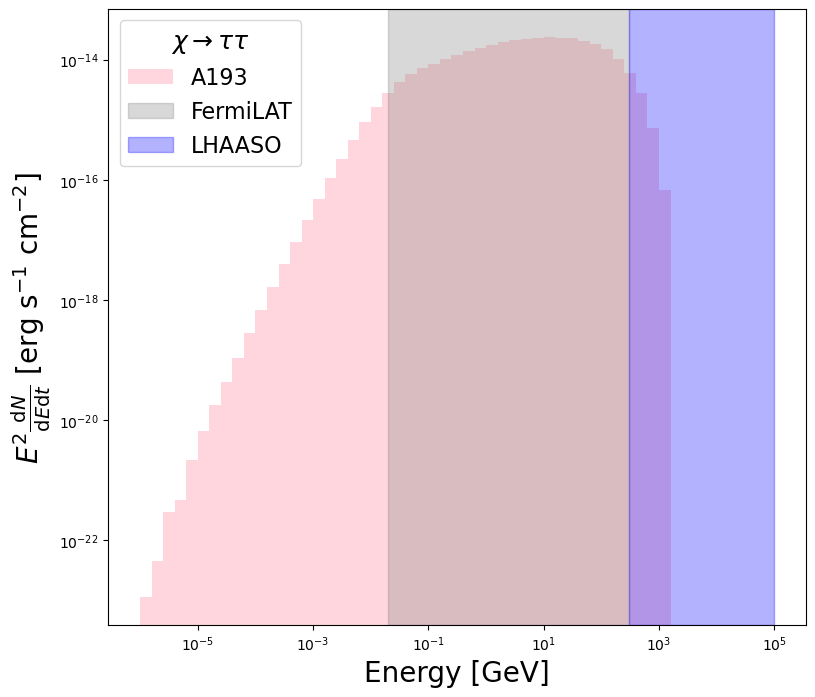

In [11]:
tau =  OptDepth.readmodel(model='saldana-lopez')
d_l = 209.18138175075842*u.Mpc
z   = 0.04910000041127205

surface = 4*np.pi*(d_l.to(u.cm))**2
atten   = np.exp(-1.*tau.opt_depth(z,e_gamma.to(u.TeV).value))

total_weight = e_weigths*dmw*e_gamma**2*atten
rate_unit    = total_weight.unit

counts_hist,_ = np.histogram(e_gamma.value,bins=engs.value,weights=total_weight.value)

nuFnu = counts_hist*(1+z)*rate_unit/binwidths/surface

_,ax = plt.subplots(figsize=(9,8))

ax.stairs(
    nuFnu.to(u.erg/u.cm**2/u.s).value,
    engs.value,
    facecolor="pink",
    fill=True,
    alpha=0.65,
    label="A193"
)
ax.axvspan(xmin=0.02,xmax=300,color='gray',alpha=0.3,label="FermiLAT")
ax.axvspan(xmin=300,xmax=1e5,color='blue',alpha=0.3,label="LHAASO")
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy [GeV]",fontsize=20)
ax.set_ylabel(r"$E^2\frac{{\rm d}N}{{\rm d}E {\rm d}t}~[\text{erg}~\text{s}^{-1}~\text{cm}^{-2}]$",fontsize=20)
ax.legend(loc="best",fontsize=16,title=r"$\chi\to\tau\tau$",title_fontsize=18)

# plt.savefig("A193_decay_nuFnu.png",dpi=300)